## 9.3 Online Retail

In [20]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [21]:
dataset = fetch_ucirepo(id=352)

df = dataset.data.original

In [22]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [23]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Preprocess

In [24]:
# Drop missing CustomerIDs
df = df.dropna(subset=['CustomerID'])

# Keep positive quantities and prices
df = df[(df['Quantity'] > 0 ) & (df['UnitPrice'] > 0)]

# Calculate total spend per row
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# Convert date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [25]:
# Defines reference snapshot data (1 day after the latest purchase)

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalSum': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Log transform to remove extreme right-skewness
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])


In [26]:
# Standardize features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [27]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

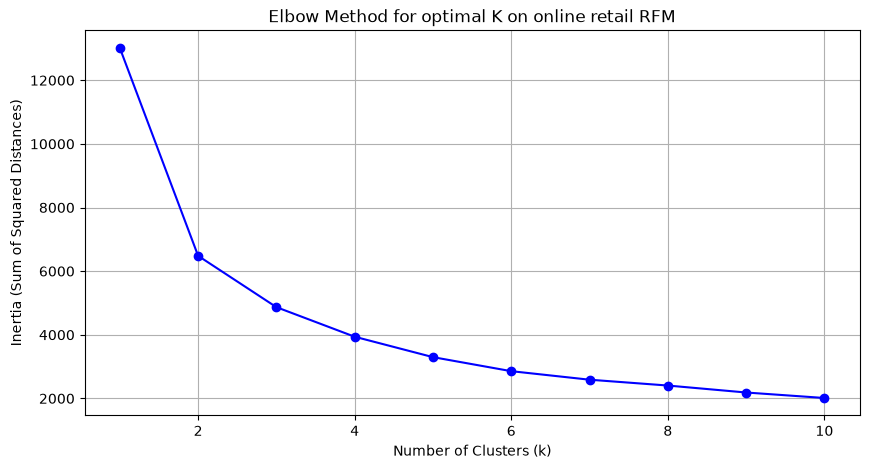

In [32]:
# Plotting the results

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'o-', color='blue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for optimal K on online retail RFM')
plt.grid(True)
plt.show()

In [33]:
# Applying K Means Clustering

kmeans = KMeans(n_clusters=3, init="k-means++", n_init="auto", random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_profile = rfm.groupby('Cluster').agg({
    "Recency": ["mean", "median"],
        "Frequency": ["mean", "median"],
        "Monetary": ["mean", "median"],
        "CustomerID": "count",  # Number of customers per cluster
})

In [34]:
display(cluster_profile)

Recency         Frequency            Monetary           CustomerID
               mean median       mean median         mean    median      count
Cluster                                                                       
0         44.463443   30.0   3.368514    3.0  1257.688940   974.230       1696
1         17.070876    9.0  13.274485   10.0  7865.636662  3705.995        776
2        167.613076  159.0   1.349411    1.0   361.539877   296.815       1866

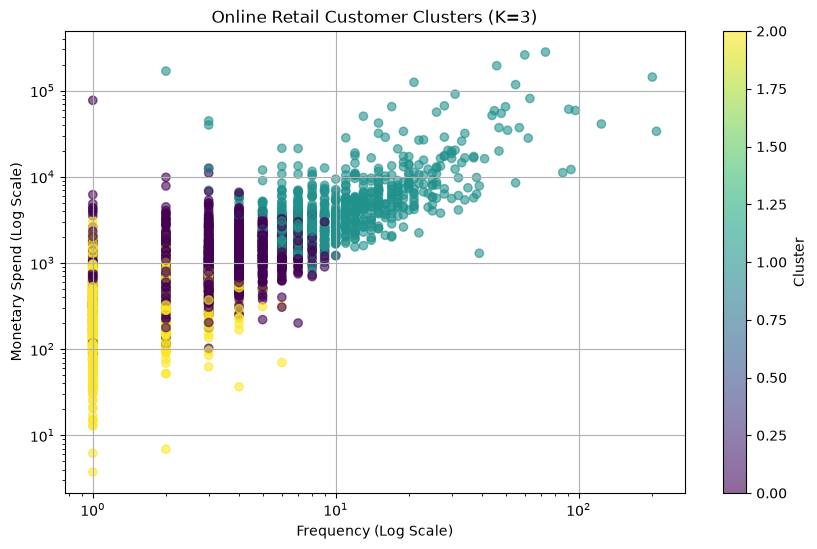

In [35]:
# 3. Plot Scatter Visualization (Frequency vs Monetary colored by Cluster)
plt.figure(figsize=(10, 6))
plt.scatter(
    x=rfm["Frequency"],
    y=rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.6,
)
plt.yscale("log")  # Using log scale for clearer visualization
plt.xscale("log")
plt.xlabel("Frequency (Log Scale)")
plt.ylabel("Monetary Spend (Log Scale)")
plt.title("Online Retail Customer Clusters (K=3)")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()